In [1]:
import sys, os
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
os.makedirs('data/graficas', exist_ok=True)

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")

2026-05-13 16:24:45.460 
  command:

    streamlit run /usr/local/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]


✅ Librerías importadas correctamente
   pandas   2.2.3
   numpy    1.26.4
   seaborn  0.13.2


In [2]:
SQL_QUERY = """
SELECT
    score,
    popularity,
    favorites,
    episodes,
    rank,
    CASE
        WHEN score >= 8.5 THEN 1
        ELSE 0
    END AS es_top_tier
FROM anime
WHERE score      IS NOT NULL
  AND popularity IS NOT NULL
  AND favorites  IS NOT NULL
  AND episodes   IS NOT NULL
  AND rank       IS NOT NULL
ORDER BY rank
"""

with engine.connect() as conn:
    df = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nBalance de la variable objetivo:")
bal = df['es_top_tier'].value_counts()
pct = df['es_top_tier'].value_counts(normalize=True) * 100
print(f"   Top Tier (score ≥ 8.5) [1]: {bal[1]:,}  ({pct[1]:.1f}%)")
print(f"   Resto   (score < 8.5) [0]: {bal[0]:,}  ({pct[0]:.1f}%)")
df.head()

✅ Datos cargados: 485 filas × 6 columnas

Columnas: ['score', 'popularity', 'favorites', 'episodes', 'rank', 'es_top_tier']

Balance de la variable objetivo:
   Top Tier (score ≥ 8.5) [1]: 164  (33.8%)
   Resto   (score < 8.5) [0]: 321  (66.2%)


,score,popularity,favorites,episodes,rank,es_top_tier
0,9.28,108,85781,28,1,1
1,9.16,650,5418,10,2,1
2,9.11,3,240854,64,3,1
3,9.09,647,12022,1,4,1
4,9.07,14,201123,24,5,1


In [3]:
print("="*55)
print("VALIDACIÓN DEL DATASET")
print("="*55)
print(f"\n📋 Tipos de datos y valores nulos:")
info = pd.DataFrame({'dtype': df.dtypes, 'nulos': df.isnull().sum()})
print(info.to_string())

print(f"\n📊 Estadísticas por clase:")
print(df.groupby('es_top_tier')[['score', 'favorites', 'popularity', 'episodes', 'rank']].describe().round(2).T)

VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
               dtype  nulos
score        float64      0
popularity     int64      0
favorites      int64      0
episodes       int64      0
rank           int64      0
es_top_tier    int64      0

📊 Estadísticas por clase:
es_top_tier               0          1
score      count     321.00     164.00
           mean        8.30       8.69
           std         0.09       0.16
           min         8.16       8.50
           25%         8.21       8.56
           50%         8.29       8.64
           75%         8.37       8.77
           max         8.49       9.28
favorites  count     321.00     164.00
           mean     8653.18   23513.21
           std     16063.21   40672.65
           min        24.00      42.00
           25%       508.00    2102.00
           50%      2921.00    8200.50
           75%      8965.00   25029.75
           max    119685.00  240854.00
popularity count     321.00     164.00
           mean  

In [4]:
FEATURES = ['popularity', 'favorites', 'episodes', 'rank']

X_raw = df[FEATURES].values
y     = df['es_top_tier'].values

# StandardScaler — OBLIGATORIO para regresión logística
# La regresión logística es sensible a la escala de las variables
# popularity puede estar en miles, favorites en cientos de miles
# Sin escalar, el optimizador puede no converger correctamente
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Features      : {FEATURES}")
print(f"X_raw shape   : {X_raw.shape}  (sin escalar)")
print(f"X_scaled shape: {X_scaled.shape}  (con StandardScaler)")
print(f"\nMedia antes de escalar  : {X_raw.mean(axis=0).round(2)}")
print(f"Media después de escalar: {X_scaled.mean(axis=0).round(4)}  (≈ 0)")
print(f"Std después de escalar  : {X_scaled.std(axis=0).round(4)}   (≈ 1)")
print(f"\n⚠️  El árbol CART NO necesita escalar. La regresión logística SÍ.")

resultados_globales = []

def evaluar_split_logit(X, y, test_size, split_label, resultados_globales):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_train, y_train)
    y_pred      = modelo.predict(X_test)
    y_pred_prob = modelo.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_pred_prob)

    pct_train = int((1 - test_size) * 100)
    pct_test  = int(test_size * 100)

    print(f"\n{'='*60}")
    print(f"  {split_label} — {pct_train}% Train / {pct_test}% Test")
    print(f"{'='*60}")
    print(f"  Train: {len(X_train):,}  |  Test: {len(X_test):,}")
    print(f"\n  📊 MÉTRICAS ({split_label})")
    print(f"  {'─'*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}  — de los que predice Top Tier, {prec*100:.1f}% lo son")
    print(f"  Recall    : {rec:.4f}  — detecta el {rec*100:.1f}% de los Top Tier reales")
    print(f"  F1-Score  : {f1:.4f}  — balance Precision/Recall")
    print(f"  ROC-AUC   : {auc:.4f}  — capacidad discriminativa del modelo")

    resultados_globales.append({
        'Split': split_label, 'Train': len(X_train), 'Test': len(X_test),
        'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1': round(f1, 4), 'AUC': round(auc, 4)
    })

    # ── Gráficas: Confusión + ROC ──────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Regresión Logística — {split_label}', fontsize=13, fontweight='bold')

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Resto (0)', 'Top Tier (1)'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Matriz de Confusión\nAcc={acc:.4f}', fontweight='bold')

    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    axes[1].plot(fpr, tpr, color='#2a5298', lw=2, label=f'ROC (AUC={auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Aleatorio')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2a5298')
    axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = f"data/graficas/logit_{split_label.replace(' ', '_').replace('/', '-')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  💾 Gráfico guardado → {fname}")

    return modelo, y_test, y_pred, y_pred_prob

Features      : ['popularity', 'favorites', 'episodes', 'rank']
X_raw shape   : (485, 4)  (sin escalar)
X_scaled shape: (485, 4)  (con StandardScaler)

Media antes de escalar  : [ 1461.27 13678.02    18.59   246.53]
Media después de escalar: [ 0.  0. -0.  0.]  (≈ 0)
Std después de escalar  : [1. 1. 1. 1.]   (≈ 1)

⚠️  El árbol CART NO necesita escalar. La regresión logística SÍ.



  Split 1 (80/20) — 80% Train / 20% Test
  Train: 388  |  Test: 97

  📊 MÉTRICAS (Split 1 (80/20))
  ──────────────────────────────────────────────────
  Accuracy  : 0.9897  (98.97%)
  Precision : 0.9706  — de los que predice Top Tier, 97.1% lo son
  Recall    : 1.0000  — detecta el 100.0% de los Top Tier reales
  F1-Score  : 0.9851  — balance Precision/Recall
  ROC-AUC   : 1.0000  — capacidad discriminativa del modelo


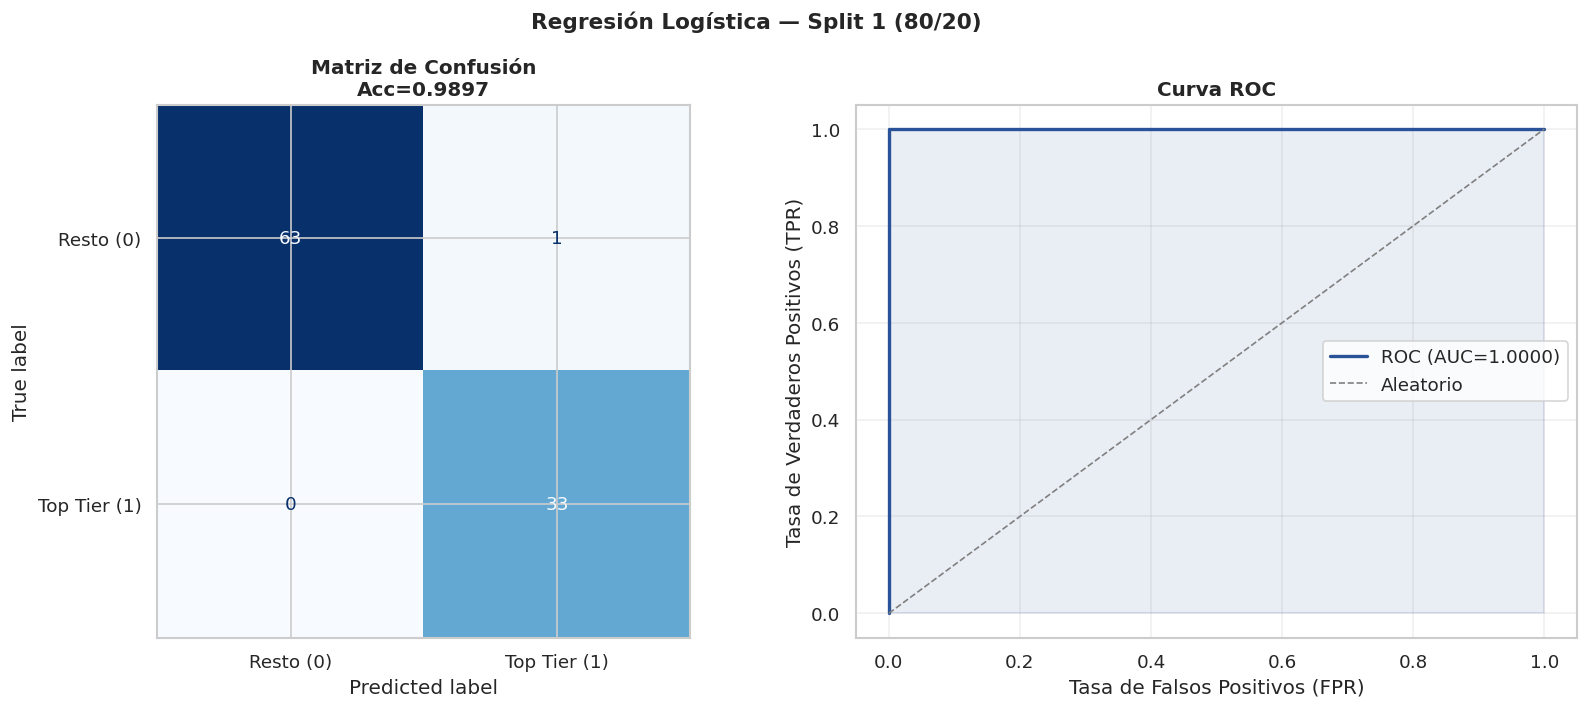

  💾 Gráfico guardado → data/graficas/logit_Split_1_(80-20).png


In [5]:
modelo_s1, y_test_s1, y_pred_s1, y_prob_s1 = evaluar_split_logit(
    X_scaled, y, test_size=0.20,
    split_label='Split 1 (80/20)',
    resultados_globales=resultados_globales,
)


  Split 2 (60/40) — 60% Train / 40% Test
  Train: 291  |  Test: 194

  📊 MÉTRICAS (Split 2 (60/40))
  ──────────────────────────────────────────────────
  Accuracy  : 0.9897  (98.97%)
  Precision : 0.9706  — de los que predice Top Tier, 97.1% lo son
  Recall    : 1.0000  — detecta el 100.0% de los Top Tier reales
  F1-Score  : 0.9851  — balance Precision/Recall
  ROC-AUC   : 0.9991  — capacidad discriminativa del modelo


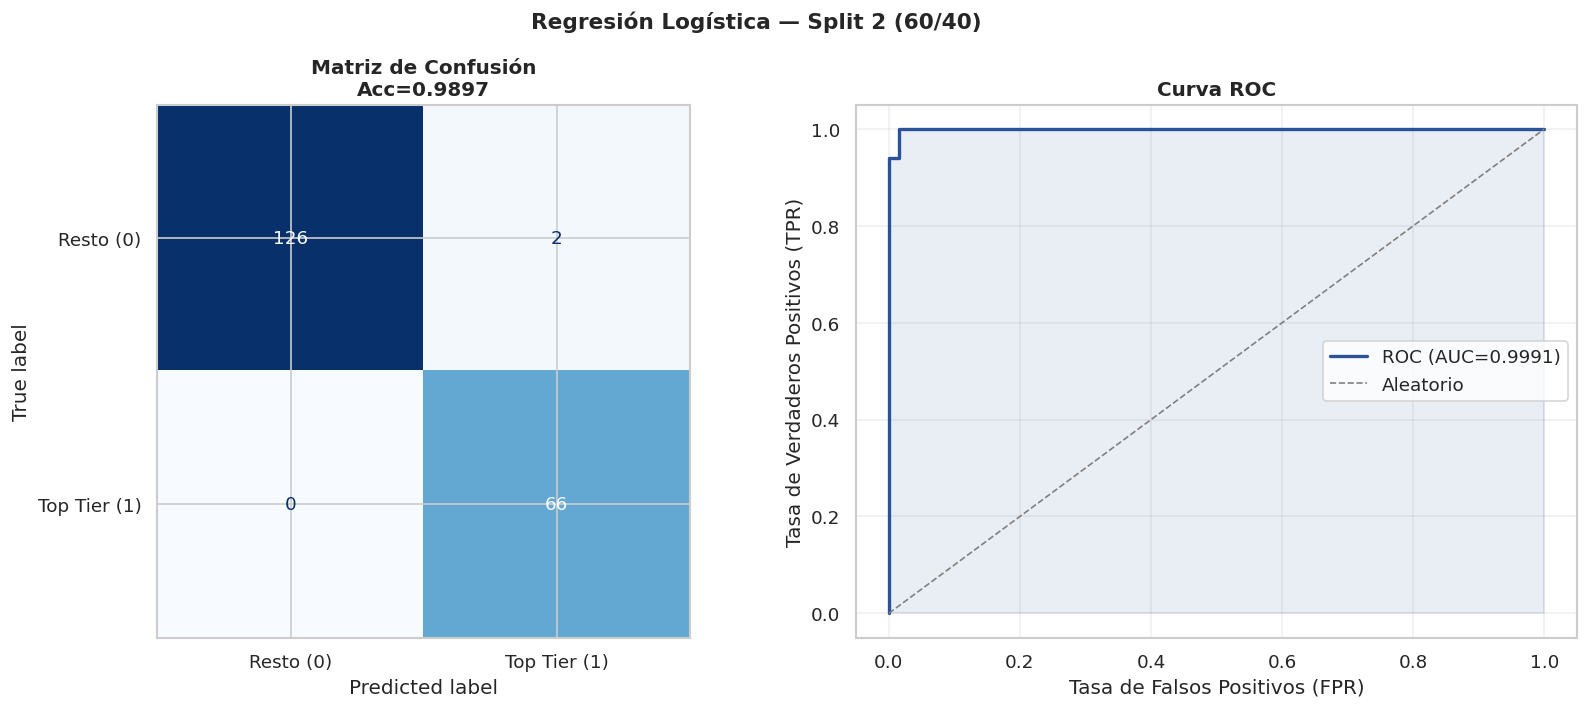

  💾 Gráfico guardado → data/graficas/logit_Split_2_(60-40).png


In [6]:
modelo_s2, y_test_s2, y_pred_s2, y_prob_s2 = evaluar_split_logit(
    X_scaled, y, test_size=0.40,
    split_label='Split 2 (60/40)',
    resultados_globales=resultados_globales,
)


  Split 3 (70/30) — 70% Train / 30% Test
  Train: 339  |  Test: 146

  📊 MÉTRICAS (Split 3 (70/30))
  ──────────────────────────────────────────────────
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000  — de los que predice Top Tier, 100.0% lo son
  Recall    : 1.0000  — detecta el 100.0% de los Top Tier reales
  F1-Score  : 1.0000  — balance Precision/Recall
  ROC-AUC   : 1.0000  — capacidad discriminativa del modelo


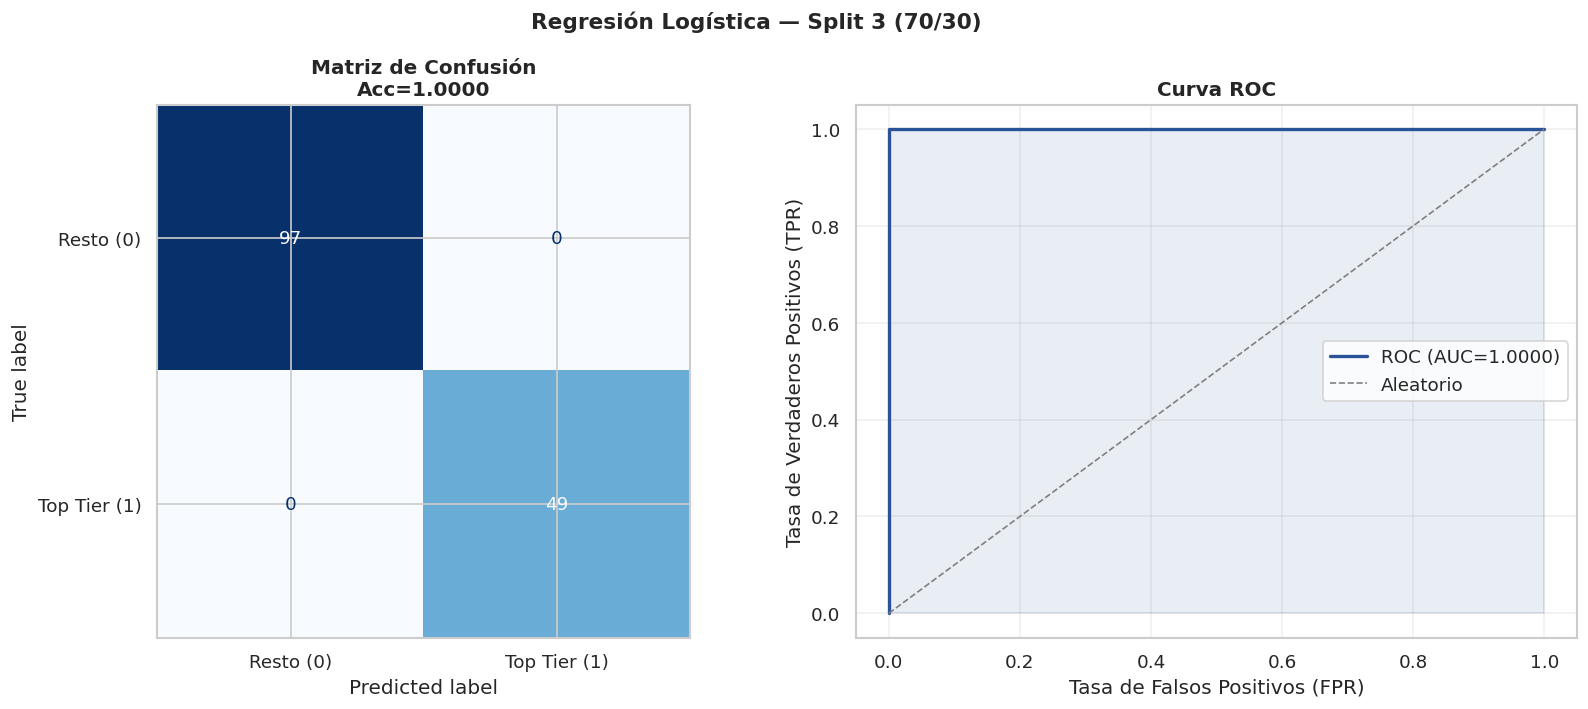

  💾 Gráfico guardado → data/graficas/logit_Split_3_(70-30).png


In [7]:
modelo_s3, y_test_s3, y_pred_s3, y_prob_s3 = evaluar_split_logit(
    X_scaled, y, test_size=0.30,
    split_label='Split 3 (70/30)',
    resultados_globales=resultados_globales,
)

📊 COEFICIENTES DEL MODELO LOGÍSTICO (Split 1 — 80/20)
   Feature  Coeficiente  Odds Ratio
 favorites     0.059144    1.060928
popularity    -0.034214    0.966365
  episodes    -0.390651    0.676616
      rank    -5.685029    0.003396

Intercepto (β₀): -3.2384

Interpretación:
  Coef > 0 → mayor valor de esa variable → más probable que sea Top Tier
  Coef < 0 → mayor valor de esa variable → menos probable que sea Top Tier
  Odds Ratio > 1 → efecto positivo en la probabilidad de Top Tier
  Odds Ratio < 1 → efecto negativo en la probabilidad de Top Tier



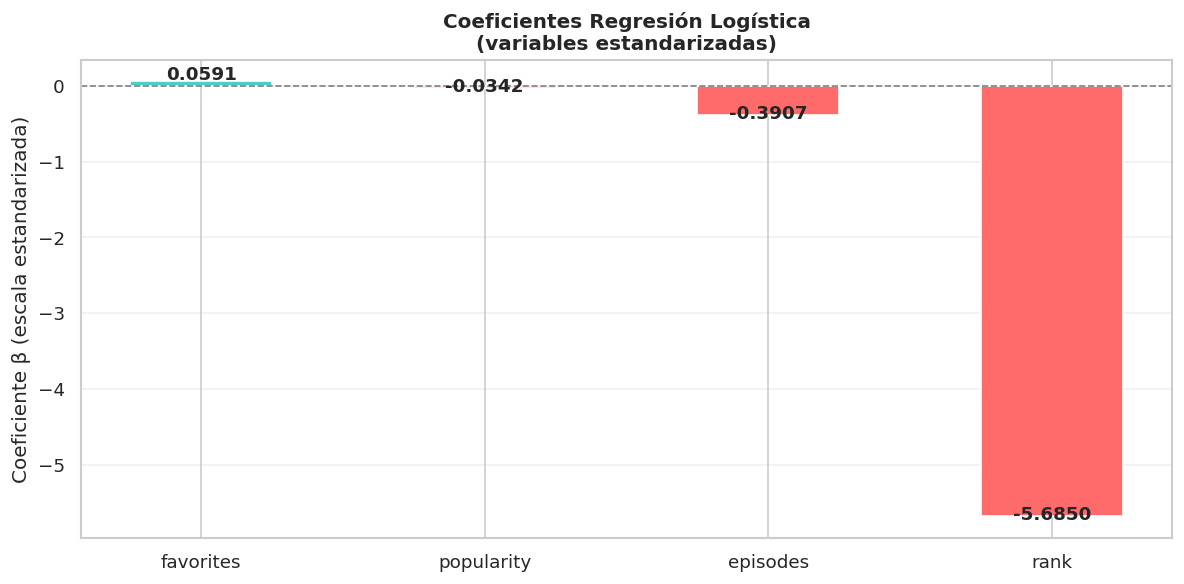

In [8]:
coefs = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coeficiente': modelo_s1.coef_[0],
    'Odds Ratio' : np.exp(modelo_s1.coef_[0])
}).sort_values('Coeficiente', ascending=False)

print("📊 COEFICIENTES DEL MODELO LOGÍSTICO (Split 1 — 80/20)")
print("="*55)
print(coefs.to_string(index=False))
print("="*55)
print(f"\nIntercepto (β₀): {modelo_s1.intercept_[0]:.4f}")
print("""
Interpretación:
  Coef > 0 → mayor valor de esa variable → más probable que sea Top Tier
  Coef < 0 → mayor valor de esa variable → menos probable que sea Top Tier
  Odds Ratio > 1 → efecto positivo en la probabilidad de Top Tier
  Odds Ratio < 1 → efecto negativo en la probabilidad de Top Tier
""")

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#4ecdc4' if c > 0 else '#ff6b6b' for c in coefs['Coeficiente']]
bars = ax.bar(coefs['Feature'], coefs['Coeficiente'],
              color=colores, edgecolor='white', width=0.5)
ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.set_title('Coeficientes Regresión Logística\n(variables estandarizadas)',
             fontweight='bold')
ax.set_ylabel('Coeficiente β (escala estandarizada)')
ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, coefs['Coeficiente']):
    offset = 0.02 if v >= 0 else -0.04
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
            f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('data/graficas/logit_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()


  TABLA COMPARATIVA — REGRESIÓN LOGÍSTICA (Top Tier Anime)
          Split  Train  Test  Accuracy  Precision  Recall     F1    AUC
Split 1 (80/20)    388    97    0.9897     0.9706     1.0 0.9851 1.0000
Split 2 (60/40)    291   194    0.9897     0.9706     1.0 0.9851 0.9991
Split 3 (70/30)    339   146    1.0000     1.0000     1.0 1.0000 1.0000


/tmp/ipykernel_784/554602771.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_resumen['Split'], rotation=15, fontsize=8)
/tmp/ipykernel_784/554602771.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_resumen['Split'], rotation=15, fontsize=8)
/tmp/ipykernel_784/554602771.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_resumen['Split'], rotation=15, fontsize=8)
/tmp/ipykernel_784/554602771.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_resumen['Split'], rotation=15, fontsize=8)
/tmp/ipykernel_784/554602771.py:20: UserWarning: set_ticklabels() should onl

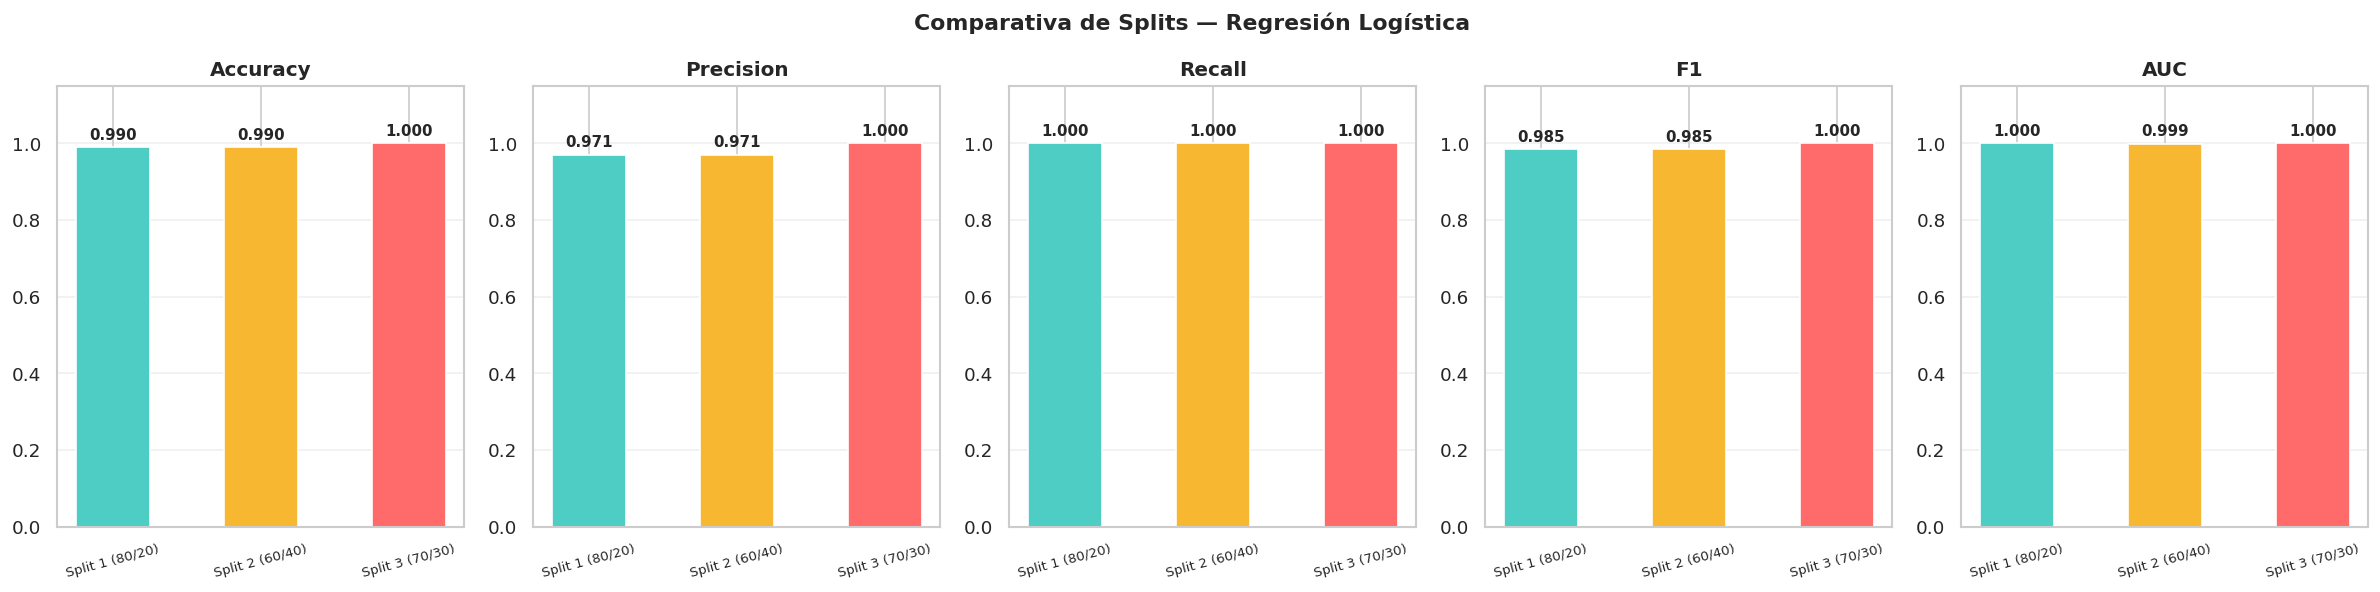


1. ESTABILIDAD DEL MODELO
   Rango Accuracy entre splits: 0.0103
   ✅ Modelo estable — la regresión logística generaliza bien

2. MEJOR SPLIT (por F1-Score)
   Split 3 (70/30)  →  F1=1.0000, AUC=1.0000

3. DIFERENCIA CLAVE CON EL ÁRBOL CART
   - Regresión Logística: requiere StandardScaler, da probabilidades calibradas
   - Árbol CART: no requiere escalar, más interpretable visualmente (plot_tree)
   - Si AUC logística > AUC árbol → logística discrimina mejor las clases
   - Si AUC árbol > AUC logística → el árbol captura mejor las no-linealidades

4. RECOMENDACIÓN
   A) Ajustar umbral de clasificación si el Recall es demasiado bajo
      (usar curva ROC para encontrar el umbral óptimo según el costo de errores)
   B) Probar C (regularización L2) con cross-validation
   C) Comparar con RandomForestClassifier como modelo más potente



In [9]:
df_resumen = pd.DataFrame(resultados_globales)

print("\n" + "="*75)
print("  TABLA COMPARATIVA — REGRESIÓN LOGÍSTICA (Top Tier Anime)")
print("="*75)
print(df_resumen.to_string(index=False))
print("="*75)

# Gráfica comparativa
metricas = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
fig, axes = plt.subplots(1, len(metricas), figsize=(20, 5))
fig.suptitle('Comparativa de Splits — Regresión Logística', fontweight='bold')

colores_splits = ['#4ecdc4', '#f7b731', '#ff6b6b']
for ax, met in zip(axes, metricas):
    vals = df_resumen[met].values
    ax.bar(df_resumen['Split'], vals, color=colores_splits, edgecolor='white', width=0.5)
    ax.set_title(met, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels(df_resumen['Split'], rotation=15, fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('data/graficas/logit_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis
acc_rango = df_resumen['Accuracy'].max() - df_resumen['Accuracy'].min()
best = df_resumen.loc[df_resumen['F1'].idxmax()]

print(f"\n1. ESTABILIDAD DEL MODELO")
print(f"   Rango Accuracy entre splits: {acc_rango:.4f}")
if acc_rango < 0.05:
    print("   ✅ Modelo estable — la regresión logística generaliza bien")
else:
    print("   ⚠️  Variación notable entre splits")

print(f"\n2. MEJOR SPLIT (por F1-Score)")
print(f"   {best['Split']}  →  F1={best['F1']:.4f}, AUC={best['AUC']:.4f}")

print("""
3. DIFERENCIA CLAVE CON EL ÁRBOL CART
   - Regresión Logística: requiere StandardScaler, da probabilidades calibradas
   - Árbol CART: no requiere escalar, más interpretable visualmente (plot_tree)
   - Si AUC logística > AUC árbol → logística discrimina mejor las clases
   - Si AUC árbol > AUC logística → el árbol captura mejor las no-linealidades

4. RECOMENDACIÓN
   A) Ajustar umbral de clasificación si el Recall es demasiado bajo
      (usar curva ROC para encontrar el umbral óptimo según el costo de errores)
   B) Probar C (regularización L2) con cross-validation
   C) Comparar con RandomForestClassifier como modelo más potente
""")